<a href="https://colab.research.google.com/github/Monika0501/Machine-Learning-Projects/blob/main/Student_Performance_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
from google.colab import files
import os

# Check if the file already exists before trying to upload
if not os.path.exists('student_performance.csv'):
    uploaded = files.upload()
    for fn in uploaded.keys():
        print('User uploaded file "{name}" with length {length} bytes'.format(
            name=fn, length=len(uploaded[fn])))
else:
    print('student_performance.csv already exists.')

# Now, try reading the CSV file again
try:
    data = pd.read_csv("student_performance.csv")
    print("File loaded successfully!")
    print(data.head())
except FileNotFoundError:
    print("Still unable to find 'student_performance.csv'. Please ensure it was uploaded correctly.")
except Exception as e:
    print(f"An error occurred: {e}")

Saving student_performance.csv to student_performance.csv
User uploaded file "student_performance.csv" with length 414 bytes
File loaded successfully!
   Study_Hours  Attendance  Previous_Score  Final_Marks
0            6          94              71           86
1            8          56              62           81
2            1          81              50           49
3            7          83              54           81
4            1          68              50           45


In [5]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Study_Hours     30 non-null     int64
 1   Attendance      30 non-null     int64
 2   Previous_Score  30 non-null     int64
 3   Final_Marks     30 non-null     int64
dtypes: int64(4)
memory usage: 1.1 KB


,Study_Hours,Attendance,Previous_Score,Final_Marks
count,30.000000,30.000000,30.000000,30.000000
mean,4.866667,77.766667,63.366667,72.433333
std,2.713101,13.743170,12.402679,14.435787
min,1.000000,56.000000,45.000000,45.000000
25%,2.000000,68.000000,51.500000,59.000000
50%,5.000000,78.500000,62.500000,77.500000
75%,6.750000,89.750000,71.750000,83.750000
max,10.000000,98.000000,86.000000,100.000000


In [6]:
data.isnull().sum()

,0
Study_Hours,0
Attendance,0
Previous_Score,0
Final_Marks,0


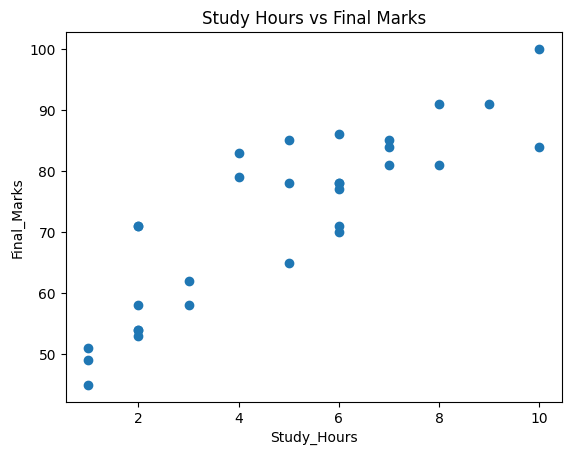

In [7]:
plt.scatter(data["Study_Hours"],data["Final_Marks"])
plt.xlabel("Study_Hours")
plt.ylabel("Final_Marks")
plt.title("Study Hours vs Final Marks")
plt.show()

In [10]:
X=data[["Study_Hours","Attendance","Previous_Score"]]
y=data["Final_Marks"]

In [12]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2, random_state=42
)

In [13]:
from sklearn.linear_model import LinearRegression

model=LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [15]:
y_pred = model.predict(X_test)

In [17]:
from sklearn.metrics import mean_squared_error, r2_score

mse= mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:",r2)

Mean Squared Error: 0.050471941573922104
R2 Score: 0.9995616429682361


In [23]:
new_student=pd.DataFrame([
    [6,80,70],
    [8, 90, 85],
    [5, 75, 65],
    [7, 85, 78]
],columns=["Study_Hours","Attendance","Previous_Score"])
prediction = model.predict(new_student)

print("Predicted Final Marks:", prediction[0])

Predicted Final Marks: 81.2828808807998


In [24]:
new_student=pd.DataFrame([
    [6,80,70],
    [8, 90, 85],
    [5, 75, 65],
    [7, 85, 78]
],columns=["Study_Hours","Attendance","Previous_Score"])
prediction = model.predict(new_student)

print("Predicted Final Marks:", prediction)


Predicted Final Marks: [81.28288088 99.99108797 72.90966623 90.8331622 ]


In [29]:
new_student["Predicted_Final_Marks"] = prediction
print(new_student)

   Study_Hours  Attendance  Previous_Score  Predicted_Final_Marks
0            6          80              70              81.282881
1            8          90              85              99.991088
2            5          75              65              72.909666
3            7          85              78              90.833162
